#**HEART** **FAILURE** **PREDICTION**
Firstly we import import required python libraries, load the dataset and explore the dataset

In [1]:
#Install TensorFlow
!pip install tensorflow

#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Now TensorFlow should import correctly
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [3]:
#Load Dataset
my_data = pd.read_csv("heartdataset.csv")

#Display First 10 Rows
my_data.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [4]:
#Check dataset structure
my_data.info()
my_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


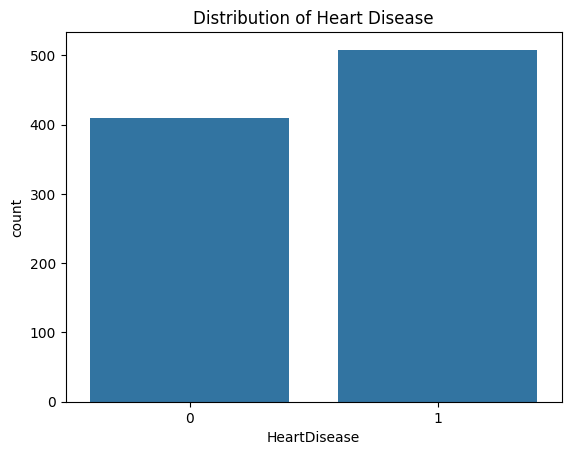

In [5]:
#Adding a simple visualisation
sns.countplot(x="HeartDisease", data=my_data)
plt.title("Distribution of Heart Disease")
#Save Figure
plt.savefig("disease_distribution.png")

#Display plot
plt.show()

In [6]:
#Split input and output
X = my_data.drop("HeartDisease", axis=1)
y = my_data["HeartDisease"]

In [7]:
#Split training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Standardize the Data

Neural networks work better when features are scaled.

In [13]:
# Making sure all column names are strings before processing
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

# Identify categorical and numerical columns based on the original data structure
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

# Apply OneHotEncoder to categorical columns
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

# Fit and transform on training data
encoded_train = encoder.fit_transform(X_train[categorical_cols])
# Create DataFrame with proper column names
encoded_train_df = pd.DataFrame(encoded_train, index=X_train.index, columns=encoder.get_feature_names_out(categorical_cols))

# Transform on test data
encoded_test = encoder.transform(X_test[categorical_cols])
encoded_test_df = pd.DataFrame(encoded_test, index=X_test.index, columns=encoder.get_feature_names_out(categorical_cols))

# Apply StandardScaler to numerical columns
scaler = StandardScaler()

# Fit and transform on training data
X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
X_train_scaled_df = pd.DataFrame(X_train_scaled, index=X_train.index, columns=numerical_cols)

# Transform on test data
X_test_scaled = scaler.transform(X_test[numerical_cols])
X_test_scaled_df = pd.DataFrame(X_test_scaled, index=X_test.index, columns=numerical_cols)

# Combine the processed numerical and categorical features
X_train_processed = pd.concat([X_train_scaled_df, encoded_train_df], axis=1)
X_test_processed = pd.concat([X_test_scaled_df, encoded_test_df], axis=1)

#Create Neural Network Function

We will train 3 neural networks.

Each one will use a different activation function.

In [9]:
#Create Neural Network Function
#We will train 3 neural networks.
#Each one will use a different activation function.
def build_model(activation, input_shape):

    model = Sequential()

    model.add(Input(shape=(input_shape,)))

    model.add(Dense(32, activation=activation))
    model.add(Dense(16, activation=activation))
    model.add(Dense(1, activation="sigmoid"))

    # IMPORTANT: compile the model
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

#Train the Models

We will test:

sigmoid\
tanh\
relu

In [14]:
#Train the models
activations = ["sigmoid", "tanh", "relu"]

histories = {}

input_shape = X_train_processed.shape[1]

for act in activations:

    model = build_model(act, input_shape)

    history = model.fit(
        X_train_processed,
        y_train,
        epochs=30,
        validation_split=0.2,
        verbose=0
    )

    histories[act] = history

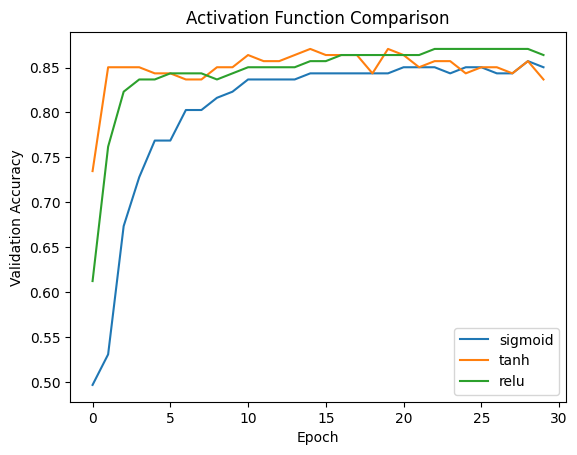

In [17]:
#Plot validation accuracy
for act in histories:

    plt.plot(histories[act].history["val_accuracy"], label=act)

plt.title("Activation Function Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

#Save figure and display plot
plt.savefig("activation_comparison.png")
plt.show()

In [18]:
#Check Data Types
print(my_data.dtypes)

#Convert Categorical Columns
my_data = pd.get_dummies(my_data, drop_first=True)

#Separate Features and Target Again
X = my_data.drop("HeartDisease", axis=1)
y = my_data["HeartDisease"]

#Convert to Numeric Arrays
X = X.astype("float32")
y = y.astype("float32")

#Split data again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Age                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
Oldpeak              float64
HeartDisease           int64
Sex_M                   bool
ChestPainType_ATA       bool
ChestPainType_NAP       bool
ChestPainType_TA        bool
RestingECG_Normal       bool
RestingECG_ST           bool
ExerciseAngina_Y        bool
ST_Slope_Flat           bool
ST_Slope_Up             bool
dtype: object


In [19]:
#Evaluate Model Performance
results = {}

input_shape = X_train.shape[1]

for act in activations:

    model = build_model(act, input_shape)

    model.fit(X_train, y_train, epochs=30, verbose=0)

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    results[act] = accuracy

print(results)

{'sigmoid': 0.7554348111152649, 'tanh': 0.7010869383811951, 'relu': 0.83152174949646}


In [20]:
#Create a table
results_df = pd.DataFrame(results.items(), columns=["Activation","Accuracy"])

results_df

,Activation,Accuracy
0,sigmoid,0.755435
1,tanh,0.701087
2,relu,0.831522


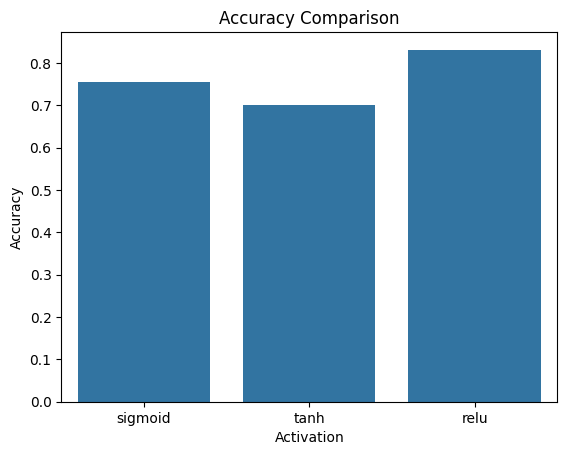

In [21]:
#Plot results
sns.barplot(x="Activation", y="Accuracy", data=results_df)

plt.title("Accuracy Comparison")
#save figure
plt.savefig("accuracy_barplot.png")

#Display plot
plt.show()

Github Reprository link
https://github.com/brymex-prog/heart-failure-prediction-neural-network